In [16]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.image import imread
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [2]:
work_dir = os.getcwd()
work_dir

'/workspaces/XrayFractureClass/jupytr_notebooks'

In [17]:
my_data_dir = '/workspaces/XrayFractureClass/data/raw/Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/second prompt test'
train_path = my_data_dir + '/train'
val_path = my_data_dir + '/validation'
test_path = my_data_dir + '/test'

In [4]:
version = 'v1'
file_path = f'outputs/{version}'

if 'outputs' in os.listdir(work_dir) and version in os.listdir(work_dir + '/outputs'):
    print('Old version is already available create a new version.')
    pass
else:
    os.makedirs(name=file_path)

Old version is already available create a new version.


In [5]:
labels = os.listdir(train_path)

print(
    f"Project Labels: {labels}"
)

Project Labels: ['fractured', 'not fractured']


In [21]:
import joblib
version = 'v1'
file_path = f'/workspaces/XrayFractureClass/outputs/{version}'
os.makedirs (file_path, exist_ok=True )

image_shape = (224, 224, 3)

joblib.dump(value=image_shape, filename=f'{file_path}/image_shape.pkl')
image_shape = joblib.load(filename=f'{file_path}/image_shape.pkl')
print (f'image_shape : {image_shape}')

image_shape : (224, 224, 3)


* train - fractured: 4606 images
* train - not fractured: 4640 images
* val - fractured: 337 images
* val - not fractured: 492 images
* test - fractured: 238 images
* test - not fractured: 268 images




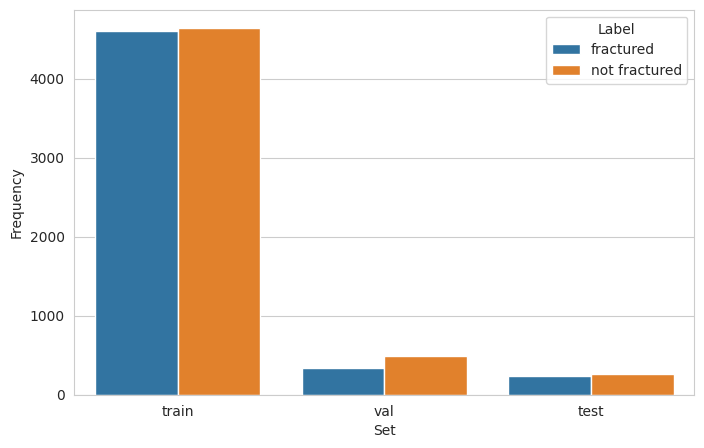

In [7]:
labels = ['fractured', 'not fractured']
file_path = '/workspaces/XrayFractureClass/outputs'
df_freq = pd.DataFrame([])

for folder in ['train', 'val', 'test']:
    for label in labels:
        freq = int(len(os.listdir(my_data_dir + '/' + folder + '/' + label)))
        
        df_freq = pd.concat([df_freq, pd.DataFrame([{'Set': folder, 'Label': label, 'Frequency': freq}])  
        ], ignore_index = True)

        print(
            f"* {folder} - {label}: {len(os.listdir(my_data_dir+'/'+ folder + '/' + label))} images")

print("\n")
sns.set_style("whitegrid")
plt.figure(figsize=(8, 5))
sns.barplot(data=df_freq, x='Set', y='Frequency', hue='Label')
plt.savefig(f'{file_path}/labels_distribution.png',
            bbox_inches='tight', dpi=150)
plt.show()

In [8]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

I0000 00:00:1779716408.861158    5242 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779716408.876280    5242 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1779716424.448153    5242 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779716434.455116    5242 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

In [9]:
augmented_image_data = ImageDataGenerator(rotation_range=20,
                                          width_shift_range=0.10,
                                          height_shift_range=0.10,
                                          shear_range=0.1,
                                          zoom_range=0.1,
                                          horizontal_flip=True,
                                          vertical_flip=True,
                                          fill_mode='nearest',
                                          rescale=1./255
                                          )

In [10]:
batch_size = 20  # Set batch size
train_set = augmented_image_data.flow_from_directory(train_path,
                                                     target_size=image_shape[:2],
                                                     color_mode='rgb',
                                                     batch_size=batch_size,
                                                     class_mode='binary',
                                                     shuffle=True
                                                     )

train_set.class_indices

Found 9246 images belonging to 2 classes.


{'fractured': 0, 'not fractured': 1}

In [11]:
validation_set = ImageDataGenerator(rescale=1./255).flow_from_directory(val_path,
                                                                        target_size=image_shape[:2],
                                                                        color_mode='rgb',
                                                                        batch_size=batch_size,
                                                                        class_mode='binary',
                                                                        shuffle=False
                                                                        )

validation_set.class_indices

FileNotFoundError: [Errno 2] No such file or directory: '/workspaces/XrayFractureClass/data/raw/Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/validation'

In [13]:
print (val_path)
print (os.path.exists(val_path))

/workspaces/XrayFractureClass/data/raw/Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/validation
False
